In [1]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats_na_dropped.geojson')
gdf = gpd.read_file(data_path)

In [2]:
from sklearn.model_selection import train_test_split


in_t = 'CODIGO_GROUP_1'
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']

train_gdf, test_gdf = train_test_split(gdf, test_size=0.2, random_state=42, stratify=gdf[in_t])

print("train set distribution:")
print(train_gdf[in_t].value_counts())
print("\n test distribution:")
print(test_gdf[in_t].value_counts())


train set distribution:
CODIGO_GROUP_1
0    532
2    483
3    342
1    154
5     32
Name: count, dtype: int64

 test distribution:
CODIGO_GROUP_1
0    133
2    121
3     85
1     39
5      8
Name: count, dtype: int64


In [3]:
label_map = {
    '0' : 'Building',
    '1' : 'Artificial Surfaces',
    '2' : 'Agriculture',
    '3' : 'Forest',
    '4' : 'Wetlands',
    '5' : 'Water'
}

target = 'OBSERV_GROUP'

train_gdf[target] = train_gdf['CODIGO_GROUP_1'].replace(label_map)

test_gdf[target] = test_gdf['CODIGO_GROUP_1'].replace(label_map)

X_train = train_gdf[features]
y_train = train_gdf[target]
X_test = test_gdf[features]
y_test = test_gdf[target]

labels = train_gdf[target].unique()
print(labels)

['Agriculture' 'Forest' 'Building' 'Artificial Surfaces' 'Water']


In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
import pandas as pd 
from sklearn.dummy import DummyClassifier

def compare_with_baseline(estimator, X_train, y_train, X_test, y_test, model_name="Model"):
    strategies = ['most_frequent', 'stratified', 'uniform'] # uniform : each class has equal proabibility to appear , stratified : 
    results = []
    
    for strategy in strategies:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        dummy.fit(X_train, y_train)
        dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
        results.append({'Model': f'Dummy ({strategy})', 'Overall Test Accuracy': dummy_acc})
    
    model_acc = accuracy_score(y_test, estimator.predict(X_test))
    results.append({'Model': model_name, 'Overall Test Accuracy': model_acc})
    
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    return df

def compute_accuracy(classifier, X_test, y_test, X_train, y_train):
    y_pred = classifier.predict(X_test)
    testing_overall_accuracy = accuracy_score(y_test, y_pred)
    training_overall_accuracy = accuracy_score(y_train, classifier.predict(X_train))
    testing_classification_accuracy= classification_report(y_test, y_pred,zero_division=1)

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

    cmd_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
    cmd.plot(ax=ax[0], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    cmd_norm.plot(ax=ax[1], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    ax[0].set_title('Confusion Matrix')
    ax[1].set_title('Normalized Confusion Matrix')
    plt.show()
    return testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy

def rf_hyperparameter_tuning(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [20, 30, 40],
        'min_samples_split': [2, 4, 6],
        'class_weight':['balanced','balanced_subsample', None], # source for this hyper param tuning : https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=cv,
        n_jobs=-1,
        verbose=0,
        scoring='f1_macro'
    )
    grid_search_rf.fit(X_train, y_train)
    return grid_search_rf


def plot_rf_feature_importances(model):
    mdi_importances = pd.Series(
        model.feature_importances_, index=features
    ).sort_values(ascending=True)
    ax = mdi_importances.plot.barh()
    ax.set_title("Random Forest Feature Importances (MDI)")
    ax.figure.tight_layout()
    return mdi_importances


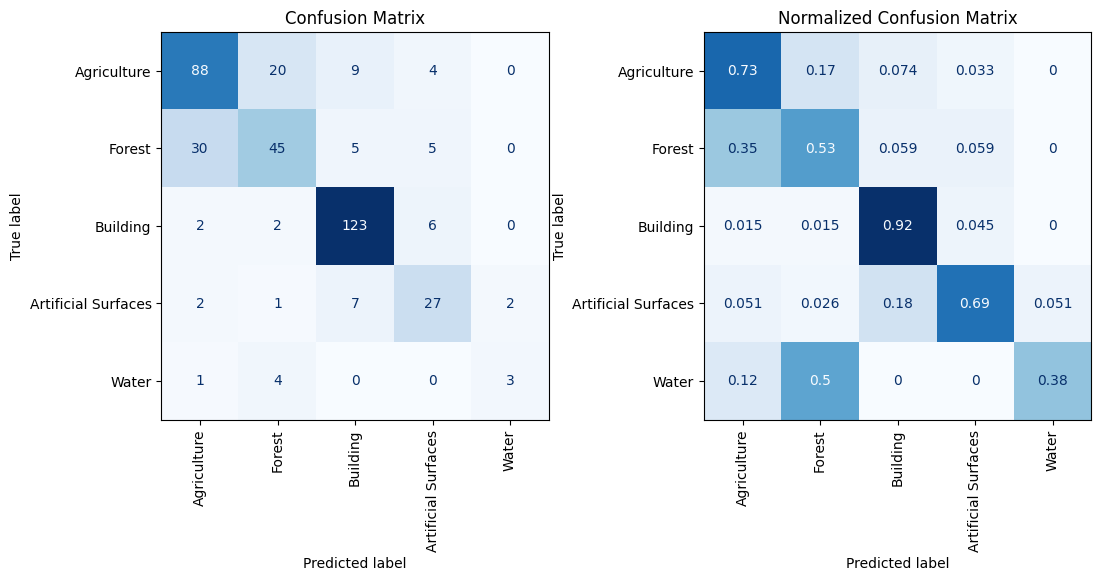


 Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_split': 6, 'n_estimators': 100}
Testing Accuracy: 0.7409326424870466
Training Accuracy: 0.9883344134802333
Testing Classification Report :
                      precision    recall  f1-score   support

        Agriculture       0.72      0.73      0.72       121
Artificial Surfaces       0.64      0.69      0.67        39
           Building       0.85      0.92      0.89       133
             Forest       0.62      0.53      0.57        85
              Water       0.60      0.38      0.46         8

           accuracy                           0.74       386
          macro avg       0.69      0.65      0.66       386
       weighted avg       0.73      0.74      0.74       386



In [5]:
grid_search_rf= rf_hyperparameter_tuning(X_train, y_train)

best_model_rf = grid_search_rf.best_estimator_

testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy = compute_accuracy(best_model_rf, X_test, y_test, X_train,y_train)
print("\n Best Hyperparameters:", grid_search_rf.best_params_)
print("Testing Accuracy:", testing_overall_accuracy)
print("Training Accuracy:", training_overall_accuracy)
print("Testing Classification Report :\n", testing_classification_accuracy)


In [34]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


def run_svm_hyperparameter_tuning(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_grid_svm = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'poly']
    }

    cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search_svm = GridSearchCV(
        estimator=SVC(random_state=42),
        param_grid=param_grid_svm,
        cv=cv_svm,
        n_jobs=-1,
        verbose=0,
        scoring='f1_macro'
    )
    grid_search_svm.fit(X_train_scaled, y_train)

    best_model_svm = grid_search_svm.best_estimator_

    testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy = compute_accuracy(best_model_svm, X_test_scaled, y_test, X_train_scaled, y_train)
    print("\n Best Hyperparameters:", grid_search_svm.best_params_)
    print("Testing Accuracy:", testing_overall_accuracy)
    print("Training Accuracy:", training_overall_accuracy)
    print("Testing Classification Report :\n", testing_classification_accuracy)
    return best_model_svm


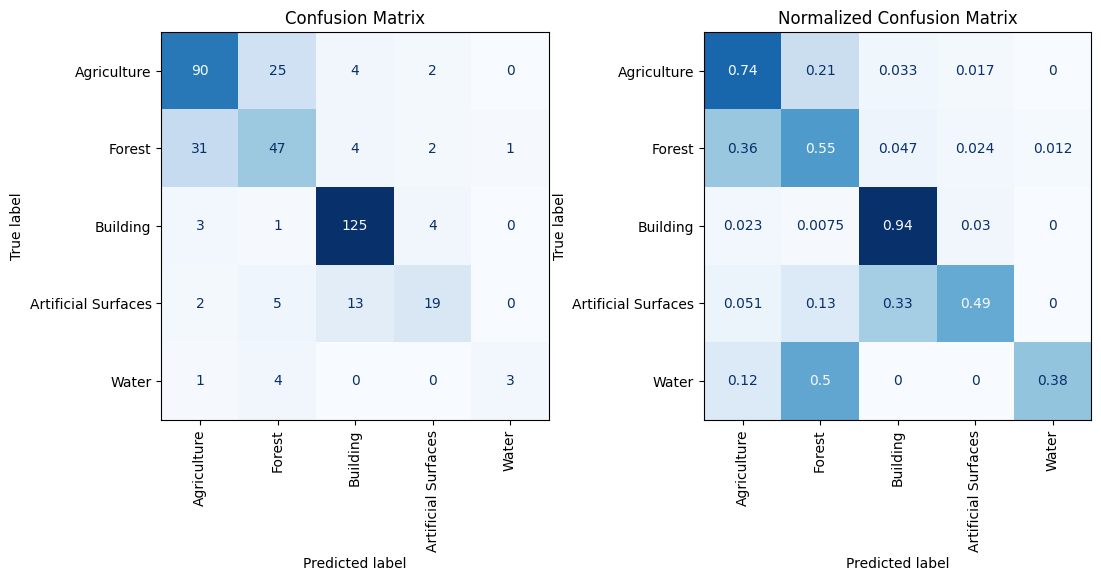


 Best Hyperparameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Testing Accuracy: 0.7357512953367875
Training Accuracy: 0.848347375243033
Testing Classification Report :
                      precision    recall  f1-score   support

        Agriculture       0.71      0.74      0.73       121
Artificial Surfaces       0.70      0.49      0.58        39
           Building       0.86      0.94      0.90       133
             Forest       0.57      0.55      0.56        85
              Water       0.75      0.38      0.50         8

           accuracy                           0.74       386
          macro avg       0.72      0.62      0.65       386
       weighted avg       0.73      0.74      0.73       386



In [35]:
best_model_svm= run_svm_hyperparameter_tuning(X_train, y_train, X_test, y_test)

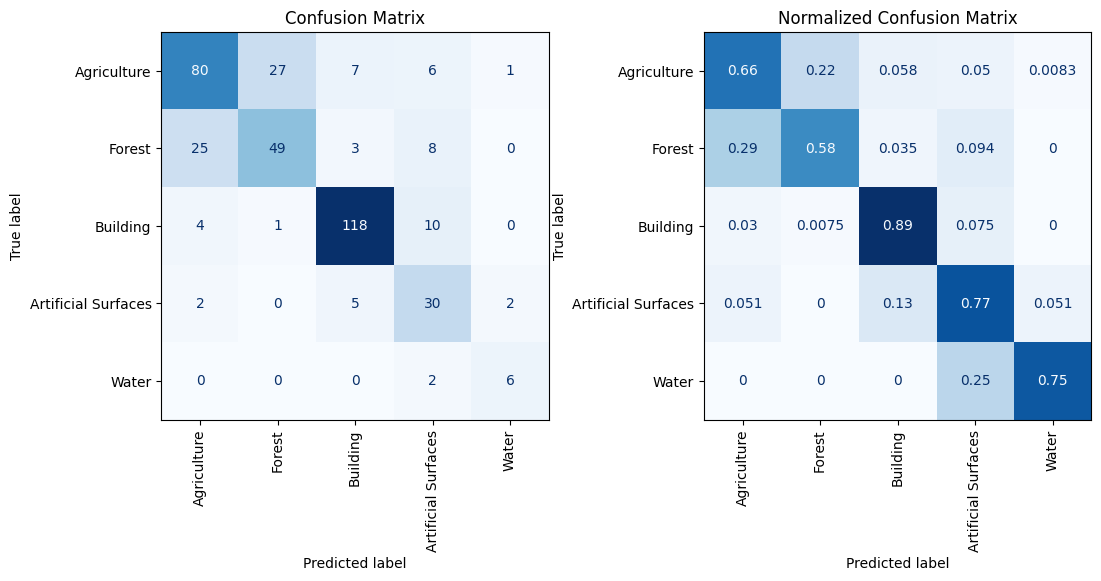


 Best Hyperparameters with SMOTE: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
Testing Accuracy: 0.7331606217616581
Training Accuracy: 0.999624060150376
Testing Classification Report:
                      precision    recall  f1-score   support

        Agriculture       0.72      0.66      0.69       121
Artificial Surfaces       0.54      0.77      0.63        39
           Building       0.89      0.89      0.89       133
             Forest       0.64      0.58      0.60        85
              Water       0.67      0.75      0.71         8

           accuracy                           0.73       386
          macro avg       0.69      0.73      0.70       386
       weighted avg       0.74      0.73      0.73       386



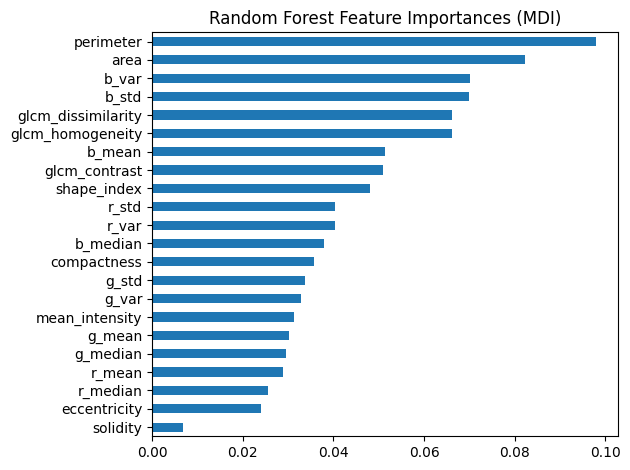

In [36]:
from imblearn.over_sampling import SMOTE # source : https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

grid_search_rf= rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy = compute_accuracy(grid_search_rf.best_estimator_, X_test, y_test, X_train_resampled, y_train_resampled)

print("\n Best Hyperparameters with SMOTE:", grid_search_rf.best_params_)

print("Testing Accuracy:", testing_overall_accuracy)
print("Training Accuracy:", training_overall_accuracy)
print("Testing Classification Report:\n", testing_classification_accuracy)

_ = plot_rf_feature_importances(grid_search_rf.best_estimator_)

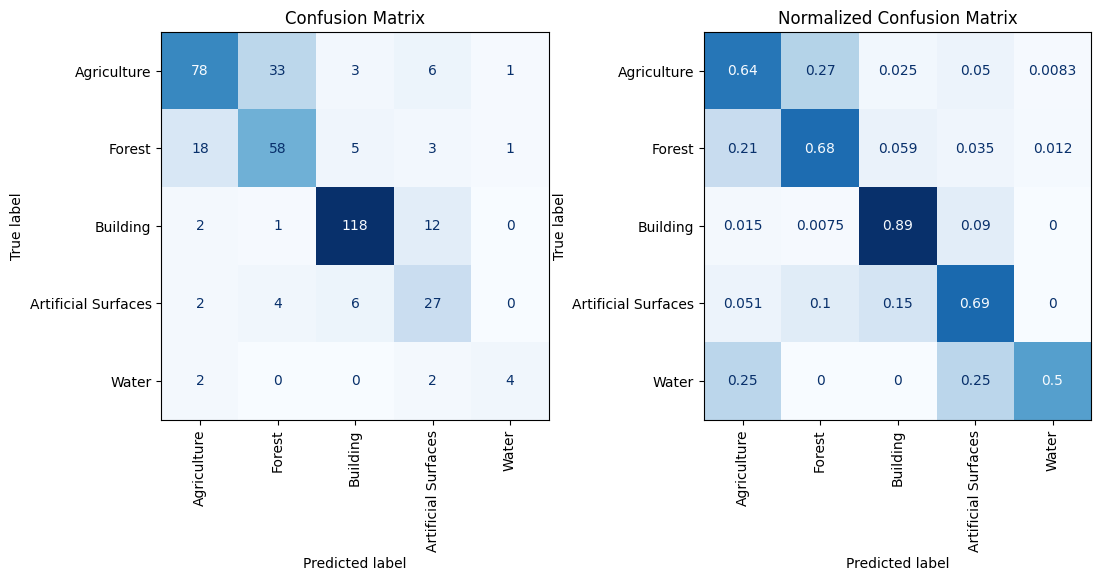


 Best Hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Testing Accuracy: 0.7383419689119171
Training Accuracy: 0.8894736842105263
Testing Classification Report :
                      precision    recall  f1-score   support

        Agriculture       0.76      0.64      0.70       121
Artificial Surfaces       0.54      0.69      0.61        39
           Building       0.89      0.89      0.89       133
             Forest       0.60      0.68      0.64        85
              Water       0.67      0.50      0.57         8

           accuracy                           0.74       386
          macro avg       0.69      0.68      0.68       386
       weighted avg       0.75      0.74      0.74       386



In [37]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

best_model_svm = run_svm_hyperparameter_tuning(X_train_resampled, y_train_resampled, X_test, y_test)

In [38]:
print("Random Forest vs Baseline:")
compare_with_baseline(best_model_rf, X_train, y_train, X_test, y_test, "Random Forest")

print("\nSVM vs Baseline:")
# compare_with_baseline(best_model_svm, X_train_scaled, y_train, X_test_scaled, y_test, "SVM")

Random Forest vs Baseline:
                Model  Overall Test Accuracy
Dummy (most_frequent)               0.344560
   Dummy (stratified)               0.295337
      Dummy (uniform)               0.202073
        Random Forest               0.740933

SVM vs Baseline:


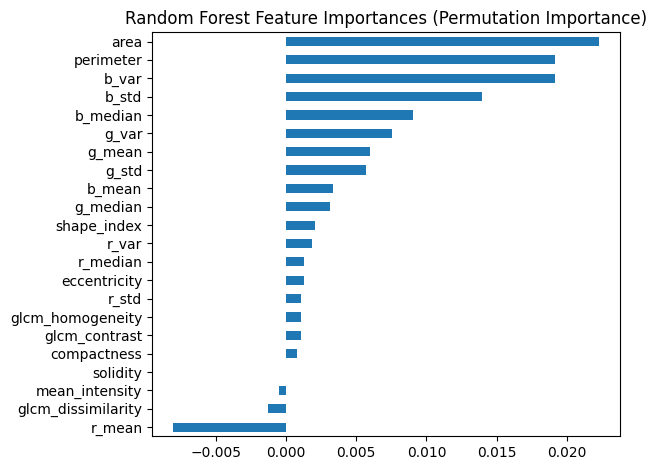

In [6]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_test, y_test):
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    perm_importances = pd.Series(result.importances_mean, index=features).sort_values(ascending=True)
    ax = perm_importances.plot.barh()
    ax.set_title("Random Forest Feature Importances (Permutation Importance)")
    ax.figure.tight_layout()
    return perm_importances

_ = plot_permutation_importance(grid_search_rf.best_estimator_, X_test, y_test)